<a href="https://colab.research.google.com/github/code-ajay-17/wheather_modal_aiml/blob/main/wheather.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor

In [ ]:
from google.colab import files
uploaded = files.upload()  # Weather_Data.csv select பண்ணு

import io
filename = list(uploaded.keys())[0]
df = pd.read_csv(io.BytesIO(uploaded[filename]))
print(f'✅ Loaded! Shape: {df.shape}')
df.head()

Saving Weather_Data.csv to Weather_Data (1).csv
✅ Loaded! Shape: (13104, 7)


,datetime,temperature,humidity,pressure,altitude,latitude,longitude
0,2021-10-26 15:40:50.284315,29.11,62.53,1005.50,64.72,10.3,79.8
1,2021-10-26 15:45:49.214095,28.95,62.30,1005.49,64.83,10.3,79.8
2,2021-10-26 15:50:49.139410,29.04,63.25,1005.55,64.32,10.3,79.8
3,2021-10-26 15:55:49.178185,29.32,63.45,1005.69,63.11,10.3,79.8
4,2021-10-26 16:00:49.229783,29.27,62.41,1005.77,62.37,10.3,79.8


In [ ]:
df = df.drop(columns=['datetime', 'latitude', 'longitude'])
df['altitude'] = df['altitude'].fillna(df['altitude'].median())
df = df[df['temperature'] <= 50].reset_index(drop=True)

print(f'✅ Cleaned Data: {df.shape}')
print(df.isnull().sum())
df.describe().round(2)

✅ Cleaned Data: (12639, 4)
temperature    0
humidity       0
pressure       0
altitude       0
dtype: int64


,temperature,humidity,pressure,altitude
count,12639.00,12639.00,12639.00,12639.00
mean,28.83,76.61,1008.45,39.56
std,0.97,3.67,8.21,20.62
min,25.29,62.30,129.40,0.01
25%,28.26,74.50,1006.96,24.81
50%,28.90,77.09,1008.74,37.60
75%,29.55,79.35,1010.27,52.47
max,31.47,93.46,1014.16,107.89


In [ ]:
X = df[['humidity', 'pressure', 'altitude']]
y_reg = df['temperature']                                        # Regression
y_cls = (df['humidity'] > df['humidity'].median()).astype(int)  # Classification

X_train, X_test, yr_train, yr_test = train_test_split(X, y_reg, test_size=0.2, random_state=42)
_,       _,      yc_train, yc_test = train_test_split(X, y_cls, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'Train: {X_train.shape[0]} | Test: {X_test.shape[0]}')

Train: 10111 | Test: 2528


📊 LINEAR REGRESSION
  MAE  : 0.6549
  MSE  : 0.7178
  RMSE : 0.8472
  R²   : 0.2583


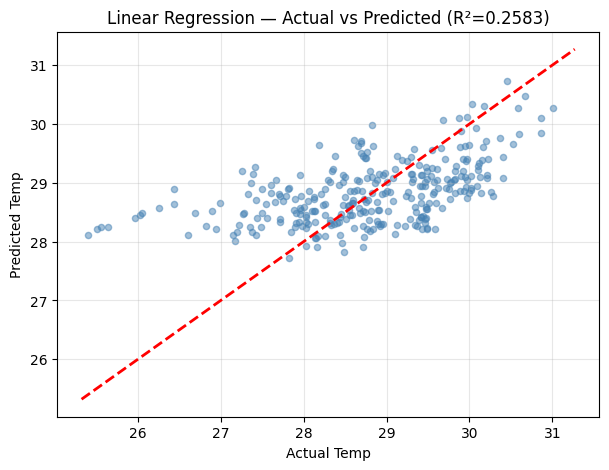

In [ ]:
lr = LinearRegression()
lr.fit(X_train, yr_train)
yr_pred_lr = lr.predict(X_test)

mae_lr  = mean_absolute_error(yr_test, yr_pred_lr)
mse_lr  = mean_squared_error(yr_test, yr_pred_lr)
rmse_lr = np.sqrt(mse_lr)
r2_lr   = r2_score(yr_test, yr_pred_lr)

print('📊 LINEAR REGRESSION')
print(f'  MAE  : {mae_lr:.4f}')
print(f'  MSE  : {mse_lr:.4f}')
print(f'  RMSE : {rmse_lr:.4f}')
print(f'  R²   : {r2_lr:.4f}')

plt.figure(figsize=(7,5))
plt.scatter(yr_test[:300], yr_pred_lr[:300], alpha=0.5, color='steelblue', s=20)
plt.plot([yr_test.min(), yr_test.max()], [yr_test.min(), yr_test.max()], 'r--', lw=2)
plt.title(f'Linear Regression — Actual vs Predicted (R²={r2_lr:.4f})')
plt.xlabel('Actual Temp'); plt.ylabel('Predicted Temp')
plt.grid(True, alpha=0.3); plt.show()

📊 LOGISTIC REGRESSION
  Accuracy : 99.76%
              precision    recall  f1-score   support

     Low Hum       1.00      1.00      1.00      1266
    High Hum       1.00      1.00      1.00      1262

    accuracy                           1.00      2528
   macro avg       1.00      1.00      1.00      2528
weighted avg       1.00      1.00      1.00      2528



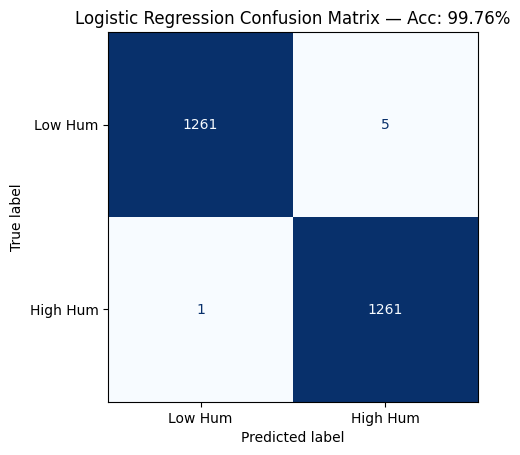

In [ ]:
logr = LogisticRegression(max_iter=1000, random_state=42)
logr.fit(X_train_sc, yc_train)
yc_pred_logr = logr.predict(X_test_sc)
acc_logr = accuracy_score(yc_test, yc_pred_logr)

print('📊 LOGISTIC REGRESSION')
print(f'  Accuracy : {acc_logr*100:.2f}%')
print(classification_report(yc_test, yc_pred_logr, target_names=['Low Hum', 'High Hum']))

ConfusionMatrixDisplay(confusion_matrix(yc_test, yc_pred_logr),
    display_labels=['Low Hum','High Hum']).plot(cmap='Blues', colorbar=False)
plt.title(f'Logistic Regression Confusion Matrix — Acc: {acc_logr*100:.2f}%')
plt.show()

📊 DECISION TREE CLASSIFIER
  Accuracy : 100.00%
              precision    recall  f1-score   support

     Low Hum       1.00      1.00      1.00      1266
    High Hum       1.00      1.00      1.00      1262

    accuracy                           1.00      2528
   macro avg       1.00      1.00      1.00      2528
weighted avg       1.00      1.00      1.00      2528



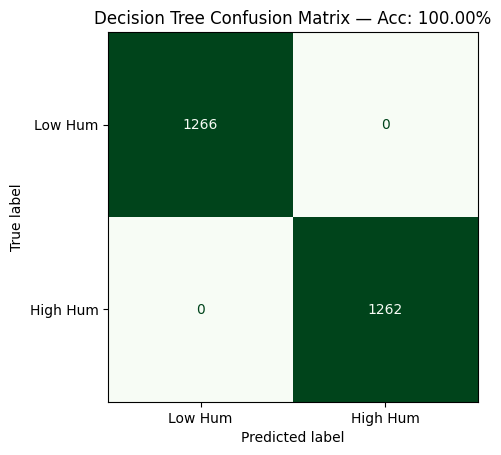

📊 DECISION TREE REGRESSOR
  MAE:0.6220  RMSE:0.8193  R²:0.3064


In [ ]:
# Classifier
dt_cls = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_cls.fit(X_train, yc_train)
yc_pred_dt = dt_cls.predict(X_test)
acc_dt = accuracy_score(yc_test, yc_pred_dt)

print('📊 DECISION TREE CLASSIFIER')
print(f'  Accuracy : {acc_dt*100:.2f}%')
print(classification_report(yc_test, yc_pred_dt, target_names=['Low Hum', 'High Hum']))

ConfusionMatrixDisplay(confusion_matrix(yc_test, yc_pred_dt),
    display_labels=['Low Hum','High Hum']).plot(cmap='Greens', colorbar=False)
plt.title(f'Decision Tree Confusion Matrix — Acc: {acc_dt*100:.2f}%')
plt.show()

# Regressor
dt_reg = DecisionTreeRegressor(max_depth=5, random_state=42)
dt_reg.fit(X_train, yr_train)
yr_pred_dt = dt_reg.predict(X_test)

mae_dt  = mean_absolute_error(yr_test, yr_pred_dt)
rmse_dt = np.sqrt(mean_squared_error(yr_test, yr_pred_dt))
r2_dt   = r2_score(yr_test, yr_pred_dt)

print('📊 DECISION TREE REGRESSOR')
print(f'  MAE:{mae_dt:.4f}  RMSE:{rmse_dt:.4f}  R²:{r2_dt:.4f}')

📊 RANDOM FOREST CLASSIFIER
  Accuracy : 100.00%
              precision    recall  f1-score   support

     Low Hum       1.00      1.00      1.00      1266
    High Hum       1.00      1.00      1.00      1262

    accuracy                           1.00      2528
   macro avg       1.00      1.00      1.00      2528
weighted avg       1.00      1.00      1.00      2528



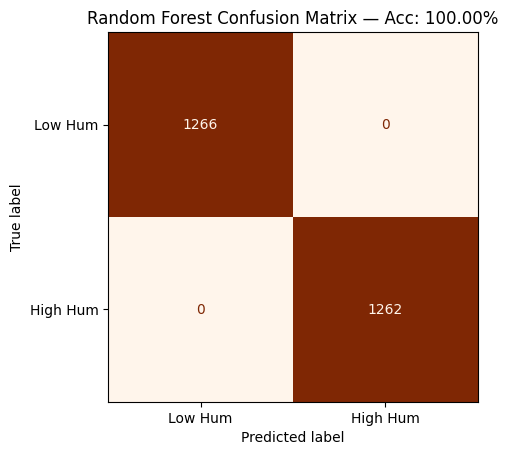

📊 RANDOM FOREST REGRESSOR
  MAE:0.6133  RMSE:0.8058  R²:0.3290


In [ ]:
# Classifier
rf_cls = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
rf_cls.fit(X_train, yc_train)
yc_pred_rf = rf_cls.predict(X_test)
acc_rf = accuracy_score(yc_test, yc_pred_rf)

print('📊 RANDOM FOREST CLASSIFIER')
print(f'  Accuracy : {acc_rf*100:.2f}%')
print(classification_report(yc_test, yc_pred_rf, target_names=['Low Hum', 'High Hum']))

ConfusionMatrixDisplay(confusion_matrix(yc_test, yc_pred_rf),
    display_labels=['Low Hum','High Hum']).plot(cmap='Oranges', colorbar=False)
plt.title(f'Random Forest Confusion Matrix — Acc: {acc_rf*100:.2f}%')
plt.show()

# Regressor
rf_reg = RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42)
rf_reg.fit(X_train, yr_train)
yr_pred_rf = rf_reg.predict(X_test)

mae_rf  = mean_absolute_error(yr_test, yr_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(yr_test, yr_pred_rf))
r2_rf   = r2_score(yr_test, yr_pred_rf)

print('📊 RANDOM FOREST REGRESSOR')
print(f'  MAE:{mae_rf:.4f}  RMSE:{rmse_rf:.4f}  R²:{r2_rf:.4f}')

REGRESSION MODELS — Temperature Prediction
            Model    MAE   RMSE     R²
Linear Regression 0.6549 0.8472 0.2583
    Decision Tree 0.6220 0.8193 0.3064
    Random Forest 0.6133 0.8058 0.3290

CLASSIFICATION MODELS — Humidity Level
              Model Accuracy
Logistic Regression   99.76%
      Decision Tree  100.00%
      Random Forest  100.00%


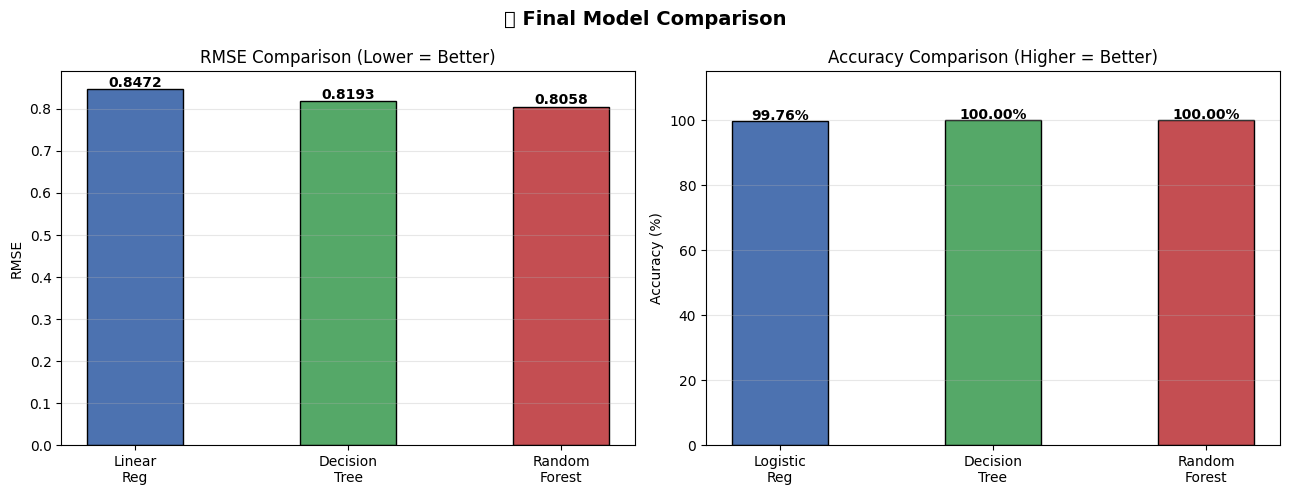


✅ Modal Trained Successfully!


In [ ]:
print('='*55)
print('REGRESSION MODELS — Temperature Prediction')
print('='*55)
reg_df = pd.DataFrame({
    'Model' : ['Linear Regression','Decision Tree','Random Forest'],
    'MAE'   : [round(mae_lr,4), round(mae_dt,4), round(mae_rf,4)],
    'RMSE'  : [round(rmse_lr,4),round(rmse_dt,4),round(rmse_rf,4)],
    'R²'    : [round(r2_lr,4),  round(r2_dt,4),  round(r2_rf,4)]
})
print(reg_df.to_string(index=False))

print('\n'+'='*55)
print('CLASSIFICATION MODELS — Humidity Level')
print('='*55)
cls_df = pd.DataFrame({
    'Model'    : ['Logistic Regression','Decision Tree','Random Forest'],
    'Accuracy' : [f'{acc_logr*100:.2f}%', f'{acc_dt*100:.2f}%', f'{acc_rf*100:.2f}%']
})
print(cls_df.to_string(index=False))

# Bar Chart
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
colors = ['#4C72B0','#55A868','#C44E52']

bars = axes[0].bar(['Linear\nReg','Decision\nTree','Random\nForest'],
                   [rmse_lr, rmse_dt, rmse_rf], color=colors, edgecolor='black', width=0.45)
for b,v in zip(bars,[rmse_lr,rmse_dt,rmse_rf]):
    axes[0].text(b.get_x()+b.get_width()/2, b.get_height()+0.005, f'{v:.4f}', ha='center', fontweight='bold')
axes[0].set_title('RMSE Comparison (Lower = Better)'); axes[0].set_ylabel('RMSE')
axes[0].grid(axis='y', alpha=0.3)

bars2 = axes[1].bar(['Logistic\nReg','Decision\nTree','Random\nForest'],
                    [acc_logr*100, acc_dt*100, acc_rf*100], color=colors, edgecolor='black', width=0.45)
for b,v in zip(bars2,[acc_logr*100, acc_dt*100, acc_rf*100]):
    axes[1].text(b.get_x()+b.get_width()/2, b.get_height()+0.3, f'{v:.2f}%', ha='center', fontweight='bold')
axes[1].set_title('Accuracy Comparison (Higher = Better)'); axes[1].set_ylabel('Accuracy (%)')
axes[1].set_ylim(0,115); axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('🏆 Final Model Comparison', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

print('\n✅ Modal Trained Successfully!')